# The Error-State Kalman Filter (ESKF)

This notebook builds an Error-State Kalman Filter for 3D motion from first principles and runs it on an IMU + 6D pose dataset. It is written in the spirit of Roger Labbe's [*Kalman and Bayesian Filters in Python*](https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python) (chapter 11 covers the EKF), and it follows the notation and equation numbers of

> J. Solà, *Quaternion kinematics for the error-state Kalman filter*, 2017. [arXiv:1711.02508](https://arxiv.org/abs/1711.02508)

**What you will see**

1. Why we filter the *error* instead of the state
2. A small quaternion toolbox (⊗, Exp, Log, ⊞, ⊟)
3. True, nominal and error state
4. Prediction: nominal kinematics and the error-state Jacobian (with a numerical check)
5. Correction: update, injection and reset
6. A dataset: 200 Hz IMU, 10 Hz 6D pose, with a 10 s measurement dropout
7. Running the filter, and comparing against pure IMU dead reckoning
8. Is the filter honest? Monte Carlo NEES and NIS consistency tests
9. Exercises

All code is written directly in this notebook, right after the theory it implements, so you can read an equation and its implementation side by side. Run the cells from top to bottom.

In [1]:
%matplotlib inline
import os
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2

plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})
np.set_printoptions(precision=4, suppress=True)

## 1. Why an *error-state* filter?

In the EKF chapter the state is estimated directly: $\mathbf x \sim \mathcal N(\hat{\mathbf x}, \mathbf P)$. That works nicely for positions and velocities. It becomes awkward for **orientation**:

* A unit quaternion has 4 numbers but only 3 degrees of freedom. A $4\times4$ covariance on it is singular in the direction that violates $\|\mathbf q\|=1$, and after every update the quaternion leaves the unit sphere and must be renormalised, which the covariance knows nothing about.
* Euler angles have 3 numbers but suffer from singularities (gimbal lock) and strong non-linearity.

The ESKF splits the problem in two:

| | **Nominal state** $\mathbf x$ | **Error state** $\delta\mathbf x$ |
|---|---|---|
| holds | the large signal (e.g. a quaternion) | the small deviation from it |
| integrated | non-linearly, no noise | linearly, carries all the noise |
| orientation | $\mathbf q \in S^3$ (4 numbers) | $\delta\boldsymbol\theta \in \mathbb R^3$ (3 numbers, minimal) |
| mean | – | always reset to **0** after a correction |

Solà (Sec. 5) lists the benefits:

* the orientation error is a minimal 3-vector, so $\mathbf P$ is never singular;
* the error stays close to zero, where the linearisation is excellent and $\sin\theta\approx\theta$ holds;
* the error dynamics are slow (the large signal is in the nominal state), so the Kalman corrections can run at a lower rate than the IMU.

The price is two extra steps after each correction: **inject** the error into the nominal state, then **reset** the error to zero.

## 2. A small quaternion toolbox

We use Hamilton quaternions $\mathbf q = [q_w, q_x, q_y, q_z]$ and the convention $\mathbf x_{world} = \mathbf R(\mathbf q)\,\mathbf x_{body}$.

The key operations (Solà Sec. 1.3) are the exponential and logarithmic maps between a rotation vector $\boldsymbol\theta = \theta\mathbf u \in \mathbb R^3$ and a unit quaternion:

$$
\mathrm{Exp}(\theta\mathbf u) = \begin{bmatrix}\cos(\theta/2)\\ \mathbf u\sin(\theta/2)\end{bmatrix},
\qquad
\mathrm{Log}(\mathbf q) = \theta\mathbf u .
$$

With them we define "plus" and "minus" on the rotation manifold, using a **local** (right-hand) perturbation, which is the convention used in this notebook:

$$
\mathbf q \boxplus \delta\boldsymbol\theta = \mathbf q \otimes \mathrm{Exp}(\delta\boldsymbol\theta),
\qquad
\mathbf q_1 \boxminus \mathbf q_0 = \mathrm{Log}(\mathbf q_0^{*} \otimes \mathbf q_1).
$$

Here is the whole toolbox:

In [2]:
def skew(v):
    """[v]x : skew-symmetric (cross-product) matrix, so that skew(a) @ b == np.cross(a, b)."""
    x, y, z = v
    return np.array([[0.0, -z, y],
                     [z, 0.0, -x],
                     [-y, x, 0.0]])


def q_mult(p, q):
    """Quaternion product p ⊗ q (Solà eq. 12)."""
    pw, px, py, pz = p
    qw, qx, qy, qz = q
    return np.array([pw*qw - px*qx - py*qy - pz*qz,
                     pw*qx + px*qw + py*qz - pz*qy,
                     pw*qy - px*qz + py*qw + pz*qx,
                     pw*qz + px*qy - py*qx + pz*qw])


def q_conj(q):
    """Conjugate q* (equal to the inverse for unit quaternions)."""
    return np.array([q[0], -q[1], -q[2], -q[3]])


def q_normalize(q):
    return q / np.linalg.norm(q)


def q_exp(rotvec):
    """Exp map: rotation vector θu in R^3  ->  unit quaternion (Solà eq. 101)."""
    rotvec = np.asarray(rotvec, dtype=float)
    theta = np.linalg.norm(rotvec)
    if theta < 1e-10:                         # small angle: first-order approximation
        return q_normalize(np.array([1.0, *(0.5 * rotvec)]))
    u = rotvec / theta
    return np.array([np.cos(theta / 2), *(np.sin(theta / 2) * u)])


def q_log(q):
    """Log map: unit quaternion  ->  rotation vector θu in R^3 (Solà eq. 105)."""
    q = np.asarray(q, dtype=float)
    if q[0] < 0:                              # q and -q are the same rotation: take the short way
        q = -q
    v = q[1:]
    nv = np.linalg.norm(v)
    if nv < 1e-10:
        return 2.0 * v
    return 2.0 * np.arctan2(nv, q[0]) * v / nv


def q_to_R(q):
    """Rotation matrix with x_world = R @ x_body (Solà eq. 115)."""
    w, x, y, z = q
    return np.array([[1 - 2*(y*y + z*z), 2*(x*y - w*z),     2*(x*z + w*y)],
                     [2*(x*y + w*z),     1 - 2*(x*x + z*z), 2*(y*z - w*x)],
                     [2*(x*z - w*y),     2*(y*z + w*x),     1 - 2*(x*x + y*y)]])


def q_boxplus(q, dtheta):
    """q ⊞ δθ = q ⊗ Exp(δθ)   (local perturbation)."""
    return q_normalize(q_mult(q, q_exp(dtheta)))


def q_boxminus(q1, q0):
    """q1 ⊟ q0 = Log(q0* ⊗ q1): the local rotation vector that takes q0 to q1."""
    return q_log(q_mult(q_conj(q0), q1))

A quick sanity check that the toolbox behaves as the maths says:

In [3]:
rng = np.random.default_rng(1)
theta = rng.normal(size=3) * 0.7
q = q_exp(theta)
print("Log(Exp(θ)) == θ        :", np.allclose(q_log(q), theta))
print("|q| == 1                :", np.isclose(np.linalg.norm(q), 1.0))

# R(q) is a proper rotation, and R(Exp(θ)) rotates θ onto itself (its own axis)
R = q_to_R(q)
print("R Rᵀ == I, det R == 1   :", np.allclose(R @ R.T, np.eye(3)), np.isclose(np.linalg.det(R), 1))
print("R θ == θ                :", np.allclose(R @ theta, theta))

# ⊞ and ⊟ are inverse operations
q0, dth = q_exp(rng.normal(size=3)), rng.normal(size=3) * 0.1
print("(q ⊞ δθ) ⊟ q == δθ      :", np.allclose(q_boxminus(q_boxplus(q0, dth), q0), dth))

# q and -q are the same rotation, Log picks the short way
print("Log(-q) == Log(q)       :", np.allclose(q_log(-q), q_log(q)))

Log(Exp(θ)) == θ        : True
|q| == 1                : True
R Rᵀ == I, det R == 1   : True True
R θ == θ                : True
(q ⊞ δθ) ⊟ q == δθ      : True
Log(-q) == Log(q)       : True


## 3. True, nominal and error state

For an IMU-driven body we use (Solà Sec. 5.3, with gravity assumed known):

$$
\underbrace{\mathbf x = \begin{bmatrix}\mathbf p\\ \mathbf v\\ \mathbf q\\ \mathbf a_b\\ \boldsymbol\omega_b\end{bmatrix}}_{\text{nominal, 16}}
\qquad
\underbrace{\delta\mathbf x = \begin{bmatrix}\delta\mathbf p\\ \delta\mathbf v\\ \delta\boldsymbol\theta\\ \delta\mathbf a_b\\ \delta\boldsymbol\omega_b\end{bmatrix}}_{\text{error, 15}}
\qquad
\mathbf x_t = \mathbf x \oplus \delta\mathbf x =
\begin{bmatrix}\mathbf p + \delta\mathbf p\\ \mathbf v + \delta\mathbf v\\ \mathbf q\otimes\mathrm{Exp}(\delta\boldsymbol\theta)\\ \mathbf a_b + \delta\mathbf a_b\\ \boldsymbol\omega_b + \delta\boldsymbol\omega_b\end{bmatrix}
$$

$\mathbf p, \mathbf v$ are position and velocity in the world frame, $\mathbf q$ is body-to-world orientation, and $\mathbf a_b, \boldsymbol\omega_b$ are the accelerometer and gyroscope biases.

The IMU measures specific force and angular rate in the body frame, corrupted by bias and white noise:

$$
\mathbf a_m = \mathbf R_t^\top(\mathbf a_t - \mathbf g) + \mathbf a_{bt} + \mathbf a_n,
\qquad
\boldsymbol\omega_m = \boldsymbol\omega_t + \boldsymbol\omega_{bt} + \boldsymbol\omega_n,
$$

and the biases follow random walks $\dot{\mathbf a}_{bt} = \mathbf a_w$, $\dot{\boldsymbol\omega}_{bt} = \boldsymbol\omega_w$.

In code, a state is a small dictionary, and the $\oplus$ / $\ominus$ operations follow the definition above directly. We index the 15-dim error state with named slices so the matrices below stay readable.

In [4]:
# where each block lives inside the 15-dim error state
P_IDX, V_IDX, TH_IDX, AB_IDX, WB_IDX = slice(0, 3), slice(3, 6), slice(6, 9), slice(9, 12), slice(12, 15)
I3 = np.eye(3)


def state_plus(x, dx):
    """x ⊕ δx : apply a 15-dim error to a nominal state."""
    return dict(p=x["p"] + dx[P_IDX],
                v=x["v"] + dx[V_IDX],
                q=q_boxplus(x["q"], dx[TH_IDX]),
                ab=x["ab"] + dx[AB_IDX],
                wb=x["wb"] + dx[WB_IDX])


def state_minus(x_true, x):
    """x_true ⊖ x : the 15-dim error that takes x to x_true."""
    return np.r_[x_true["p"] - x["p"],
                 x_true["v"] - x["v"],
                 q_boxminus(x_true["q"], x["q"]),
                 x_true["ab"] - x["ab"],
                 x_true["wb"] - x["wb"]]

## 4. Prediction

### 4.1 Nominal state (non-linear, no noise)

Discretised with step $\Delta t$ (Solà eq. 260):

$$
\begin{aligned}
\mathbf p &\leftarrow \mathbf p + \mathbf v\Delta t + \tfrac12\big(\mathbf R(\mathbf a_m - \mathbf a_b) + \mathbf g\big)\Delta t^2\\
\mathbf v &\leftarrow \mathbf v + \big(\mathbf R(\mathbf a_m - \mathbf a_b) + \mathbf g\big)\Delta t\\
\mathbf q &\leftarrow \mathbf q \otimes \mathrm{Exp}\big((\boldsymbol\omega_m - \boldsymbol\omega_b)\Delta t\big)\\
\mathbf a_b &\leftarrow \mathbf a_b, \qquad \boldsymbol\omega_b \leftarrow \boldsymbol\omega_b
\end{aligned}
$$

### 4.2 Error state (linear, carries the noise)

The error mean is zero and stays zero during prediction, so only its covariance moves:

$$
\mathbf P \leftarrow \mathbf F_x\,\mathbf P\,\mathbf F_x^\top + \mathbf F_i\,\mathbf Q_i\,\mathbf F_i^\top
$$

with the error-state transition matrix (Solà eq. 269)

$$
\mathbf F_x = \begin{bmatrix}
\mathbf I & \mathbf I\Delta t & 0 & 0 & 0\\
0 & \mathbf I & -\mathbf R[\mathbf a_m-\mathbf a_b]_\times\Delta t & -\mathbf R\Delta t & 0\\
0 & 0 & \mathbf R^\top\{(\boldsymbol\omega_m-\boldsymbol\omega_b)\Delta t\} & 0 & -\mathbf I\Delta t\\
0 & 0 & 0 & \mathbf I & 0\\
0 & 0 & 0 & 0 & \mathbf I
\end{bmatrix}
$$

and the noise mapping $\mathbf F_i$ (noise enters $\delta\mathbf v, \delta\boldsymbol\theta, \delta\mathbf a_b, \delta\boldsymbol\omega_b$) with

$$
\mathbf Q_i = \mathrm{diag}\big(\sigma_{a_n}^2\Delta t^2\,\mathbf I,\;
\sigma_{\omega_n}^2\Delta t^2\,\mathbf I,\;
\sigma_{a_w}^2\Delta t\,\mathbf I,\;
\sigma_{\omega_w}^2\Delta t\,\mathbf I\big).
$$

The interesting entry is $-\mathbf R[\mathbf a]_\times\Delta t$: an orientation error tilts the measured specific force, so a small $\delta\boldsymbol\theta$ leaks gravity into the velocity. This coupling is what makes attitude observable from position measurements, and also what makes dead reckoning drift so quickly.

The three functions below implement exactly these equations.

In [5]:
@dataclass
class ESKFParams:
    """IMU noise parameters (discrete, per sample), Solà eq. (262)."""
    sigma_an: float = 0.05     # accelerometer white noise        [m/s²]
    sigma_wn: float = 0.005    # gyroscope white noise            [rad/s]
    sigma_aw: float = 0.002    # accelerometer bias random walk   [m/s² / √s]
    sigma_ww: float = 0.0002   # gyroscope bias random walk       [rad/s / √s]
    gravity: tuple = (0.0, 0.0, -9.81)


def nominal_predict(x, a_m, w_m, dt, g):
    """Nominal state kinematics, no noise (Solà eq. 260)."""
    R = q_to_R(x["q"])
    acc_world = R @ (a_m - x["ab"]) + g        # remove bias, rotate to world, add gravity
    return dict(p=x["p"] + x["v"] * dt + 0.5 * acc_world * dt**2,
                v=x["v"] + acc_world * dt,
                q=q_boxplus(x["q"], (w_m - x["wb"]) * dt),
                ab=x["ab"].copy(),             # biases are constant in the nominal model
                wb=x["wb"].copy())


def error_state_jacobian(x, a_m, w_m, dt):
    """F_x = ∂δx_{k+1} / ∂δx_k (Solà eq. 269)."""
    R = q_to_R(x["q"])
    a = a_m - x["ab"]
    w = w_m - x["wb"]
    Fx = np.eye(15)
    Fx[P_IDX, V_IDX]   = I3 * dt
    Fx[V_IDX, TH_IDX]  = -R @ skew(a) * dt       # attitude error tilts gravity into velocity
    Fx[V_IDX, AB_IDX]  = -R * dt
    Fx[TH_IDX, TH_IDX] = q_to_R(q_exp(w * dt)).T
    Fx[TH_IDX, WB_IDX] = -I3 * dt
    return Fx


def process_noise(params, dt):
    """F_i Q_i F_iᵀ (Solà eqs. 270-271). Noise enters δv, δθ, δa_b, δω_b but not δp."""
    Fi = np.zeros((15, 12))
    Fi[3:15, :] = np.eye(12)
    Qi = np.diag(np.r_[np.full(3, params.sigma_an**2 * dt**2),
                       np.full(3, params.sigma_wn**2 * dt**2),
                       np.full(3, params.sigma_aw**2 * dt),
                       np.full(3, params.sigma_ww**2 * dt)])
    return Fi @ Qi @ Fi.T

### 4.3 Checking $\mathbf F_x$ numerically

Derivations are easy to get wrong, so we verify them. We perturb the error state by a tiny $\delta\mathbf x$ in each direction, propagate both the nominal state and the perturbed ("true") state with the *non-linear* model, and measure how the error changed. The ratio is a column of $\mathbf F_x$.

largest |F_analytic - F_numeric| per 3x3 block   (dt = 0.01)
                δp        δv        δθ      δa_b      δω_b
    δp     7.3e-13   5.9e-14   4.3e-04   4.7e-05   0.0e+00
    δv     0.0e+00   8.2e-11   4.7e-08   3.8e-11   0.0e+00
    δθ     0.0e+00   0.0e+00   6.0e-11   0.0e+00   1.4e-05
  δa_b     0.0e+00   0.0e+00   0.0e+00   1.0e-12   0.0e+00
  δω_b     0.0e+00   0.0e+00   0.0e+00   0.0e+00   1.0e-12


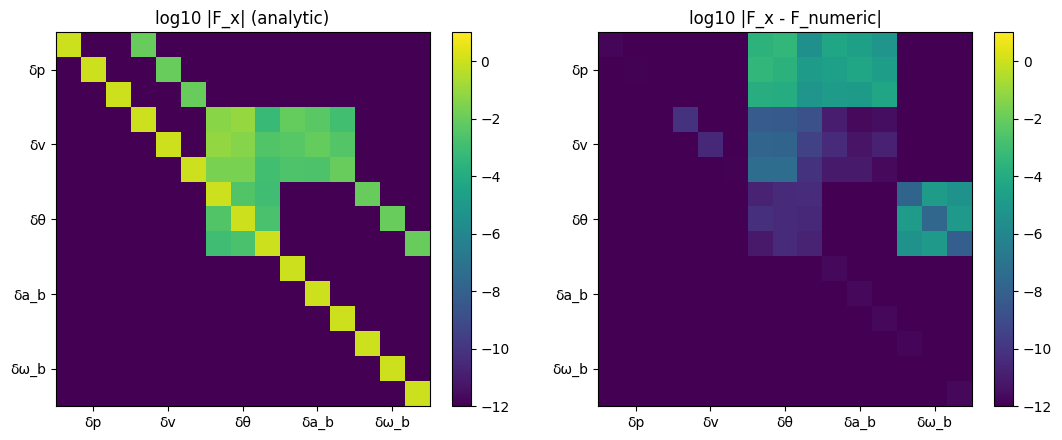

In [6]:
params = ESKFParams()
g = np.array(params.gravity)
x = dict(p=np.zeros(3), v=np.array([1.0, 0.5, 0.0]), q=q_exp([0.3, -0.2, 0.5]),
         ab=np.array([0.05, 0.02, -0.03]), wb=np.array([0.01, 0.0, 0.02]))
a_m, w_m, dt = np.array([0.3, -0.2, 9.9]), np.array([0.2, -0.1, 0.3]), 0.01

x_next = nominal_predict(x, a_m, w_m, dt, g)
F_num, eps = np.zeros((15, 15)), 1e-6
for i in range(15):
    d = np.zeros(15); d[i] = eps
    x_true_next = nominal_predict(state_plus(x, d), a_m, w_m, dt, g)   # propagate the perturbed state
    F_num[:, i] = state_minus(x_true_next, x_next) / eps               # how did the error change?

F_ana = error_state_jacobian(x, a_m, w_m, dt)
diff = np.abs(F_ana - F_num)
print(f"largest |F_analytic - F_numeric| per 3x3 block   (dt = {dt})")
names = ["δp", "δv", "δθ", "δa_b", "δω_b"]
print("        " + "".join(f"{n:>10}" for n in names))
for r in range(5):
    print(f"{names[r]:>6}  " + "".join(f"{diff[3*r:3*r+3, 3*c:3*c+3].max():10.1e}" for c in range(5)))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for a, M, title in [(ax[0], np.log10(np.abs(F_ana) + 1e-12), "log10 |F_x| (analytic)"),
                    (ax[1], np.log10(diff + 1e-12), "log10 |F_x - F_numeric|")]:
    im = a.imshow(M, cmap="viridis", vmin=-12, vmax=1)
    a.set_xticks(np.arange(1, 15, 3), names); a.set_yticks(np.arange(1, 15, 3), names)
    a.set_title(title); a.grid(False); plt.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout()

Almost every block agrees to numerical precision. Three blocks show a small but real mismatch:

* $\delta\mathbf p$ w.r.t. $\delta\boldsymbol\theta$ and $\delta\mathbf a_b$. The nominal position update contains $\tfrac12\mathbf R(\mathbf a_m-\mathbf a_b)\Delta t^2$, and the analytic $\mathbf F_x$ drops its sensitivity to attitude and bias. The missing terms are $-\tfrac12\mathbf R[\mathbf a]_\times\Delta t^2$ and $-\tfrac12\mathbf R\Delta t^2$.
* $\delta\boldsymbol\theta$ w.r.t. $\delta\boldsymbol\omega_b$. The exact block is $-\mathbf J_r\big((\boldsymbol\omega_m-\boldsymbol\omega_b)\Delta t\big)\Delta t$, with $\mathbf J_r$ the right Jacobian of SO(3). Solà approximates $\mathbf J_r\approx\mathbf I$, which is off by $O(\|\boldsymbol\omega\|\Delta t^2)$.

All three are second order in $\Delta t$ and are dropped on purpose. You can confirm this by rerunning the cell with `dt = 0.001`: these entries shrink by a factor of 100, while a genuine derivation error would only shrink by 10 or not at all. The tiny values elsewhere are finite-difference noise. Exercise 1 asks you to add the missing terms.

## 5. Correction: update, inject, reset

### 5.1 Update

A measurement $\mathbf y = h(\mathbf x_t) + \mathbf v$, $\mathbf v\sim\mathcal N(0,\mathbf V)$, is used in the usual Kalman way, but the Jacobian is taken **with respect to the error state** (Solà eqs. 274-278):

$$
\mathbf K = \mathbf P\mathbf H^\top(\mathbf H\mathbf P\mathbf H^\top + \mathbf V)^{-1},
\qquad
\delta\hat{\mathbf x} = \mathbf K\,\mathbf r,
\qquad
\mathbf P \leftarrow (\mathbf I-\mathbf K\mathbf H)\mathbf P(\mathbf I-\mathbf K\mathbf H)^\top + \mathbf K\mathbf V\mathbf K^\top .
$$

For a **6D pose** measurement $(\mathbf p_m, \mathbf q_m)$, the kind a pose estimator, a motion-capture system or a visual marker would give you, we write the residual directly in the tangent space:

$$
\mathbf r = \begin{bmatrix}\mathbf p_m - \mathbf p\\ \mathbf q_m \boxminus \mathbf q\end{bmatrix},
\qquad
\mathbf H = \begin{bmatrix}\mathbf I & 0 & 0 & 0 & 0\\ 0 & 0 & \mathbf I & 0 & 0\end{bmatrix}.
$$

Because the orientation residual is already a local rotation vector, its Jacobian w.r.t. $\delta\boldsymbol\theta$ is simply $\mathbf I$ (to first order). No $4\times3$ quaternion Jacobian is needed. This is one of the practical conveniences of the error-state formulation.

### 5.2 Inject

The estimated error is folded into the nominal state (Solà eq. 282):

$$
\mathbf p \leftarrow \mathbf p + \delta\hat{\mathbf p},\quad
\mathbf v \leftarrow \mathbf v + \delta\hat{\mathbf v},\quad
\mathbf q \leftarrow \mathbf q \otimes \mathrm{Exp}(\delta\hat{\boldsymbol\theta}),\quad
\mathbf a_b \leftarrow \mathbf a_b + \delta\hat{\mathbf a}_b,\quad
\boldsymbol\omega_b \leftarrow \boldsymbol\omega_b + \delta\hat{\boldsymbol\omega}_b
$$

### 5.3 Reset

After injection the error mean is zero again. The orientation error is, however, now defined relative to a *new* nominal quaternion, so the covariance is re-expressed around it (Solà eqs. 285-287):

$$
\mathbf P \leftarrow \mathbf G\,\mathbf P\,\mathbf G^\top,
\qquad
\mathbf G = \mathrm{diag}\big(\mathbf I,\ \mathbf I,\ \mathbf I - [\tfrac12\delta\hat{\boldsymbol\theta}]_\times,\ \mathbf I,\ \mathbf I\big).
$$

In practice $\mathbf G\approx\mathbf I$ and many implementations skip it. We keep it for correctness.

The class below puts prediction and correction together. It is the complete filter.

In [7]:
class ESKF:
    """Error-State Kalman Filter: IMU prediction + position / 6D pose correction."""

    def __init__(self, params, x0, P0):
        self.params = params
        self.g = np.array(params.gravity, dtype=float)
        x0 = {"ab": np.zeros(3), "wb": np.zeros(3), **x0}                # biases default to zero
        self.x = {k: np.array(v, dtype=float) for k, v in x0.items()}   # nominal state
        self.P = np.array(P0, dtype=float)                               # error-state covariance

    # ---------------- prediction (Section 4) ----------------
    def predict(self, a_m, w_m, dt):
        Fx = error_state_jacobian(self.x, a_m, w_m, dt)   # linearise at the current nominal state
        self.P = Fx @ self.P @ Fx.T + process_noise(self.params, dt)
        self.x = nominal_predict(self.x, a_m, w_m, dt, self.g)

    # ---------------- correction (Section 5) ----------------
    def correct(self, r, H, V):
        """Update -> inject -> reset. Returns the NIS of this measurement."""
        S = H @ self.P @ H.T + V                           # innovation covariance
        K = self.P @ H.T @ np.linalg.inv(S)                # Kalman gain
        dx = K @ r                                         # 5.1 estimated error
        IKH = np.eye(15) - K @ H
        self.P = IKH @ self.P @ IKH.T + K @ V @ K.T        #     Joseph form, stays symmetric PD

        self.x = state_plus(self.x, dx)                    # 5.2 inject the error into the nominal state

        G = np.eye(15)                                     # 5.3 reset the error around the new nominal
        G[TH_IDX, TH_IDX] = I3 - skew(0.5 * dx[TH_IDX])
        self.P = G @ self.P @ G.T
        return float(r @ np.linalg.solve(S, r))

    # ---------------- measurement models ----------------
    def update_position(self, p_meas, sigma_p):
        """y = p + noise"""
        H = np.zeros((3, 15)); H[:, P_IDX] = I3
        r = p_meas - self.x["p"]
        return self.correct(r, H, np.eye(3) * sigma_p**2)

    def update_pose(self, p_meas, q_meas, sigma_p, sigma_theta):
        """Full 6D pose. Orientation residual lives in the tangent space: r_θ = q_meas ⊟ q."""
        H = np.zeros((6, 15)); H[0:3, P_IDX] = I3; H[3:6, TH_IDX] = I3
        r = np.r_[p_meas - self.x["p"], q_boxminus(q_meas, self.x["q"])]
        V = np.diag(np.r_[np.full(3, sigma_p**2), np.full(3, sigma_theta**2)])
        return self.correct(r, H, V)

## 6. The dataset

The simulator below generates a slowly manoeuvring vehicle, for example an ROV. Truth is produced with the same discretisation as the filter, so any inconsistency we find later comes from the filter and not from the simulator.

| sensor | rate | noise |
|---|---|---|
| IMU (accelerometer + gyroscope) | 200 Hz | $\sigma_{a_n}=0.05$ m/s², $\sigma_{\omega_n}=0.005$ rad/s, biases with random walk |
| 6D pose | 10 Hz | $\sigma_p = 5$ cm, $\sigma_\theta = 2°$ |

Between $t = 30$ s and $t = 40$ s there are **no pose measurements**, which mimics an occlusion or a detector failure. During that window the filter can only integrate the IMU.

The data is also written to `data/` as plain CSV, so you can swap in your own logs with the same columns and skip the simulation:

* `imu.csv`: `t, ax, ay, az, wx, wy, wz` (body frame, m/s² and rad/s)
* `pose_measurements.csv`: `t, px, py, pz, qw, qx, qy, qz`
* `ground_truth.csv` (optional): `t, px..pz, vx..vz, qw..qz, abx..abz, wbx..wbz`

In [8]:
@dataclass
class SimConfig:
    duration: float = 60.0
    imu_rate: float = 200.0
    pose_rate: float = 10.0
    dropout: tuple = (30.0, 40.0)            # seconds without pose measurements
    sigma_an: float = 0.05                   # IMU errors: must match ESKFParams for a consistent filter
    sigma_wn: float = 0.005
    sigma_aw: float = 0.002
    sigma_ww: float = 0.0002
    ab0: tuple = (0.08, -0.05, 0.10)         # true initial biases
    wb0: tuple = (0.010, -0.008, 0.012)
    sigma_p: float = 0.05                    # pose sensor noise [m]
    sigma_theta: float = np.deg2rad(2.0)     # pose sensor noise [rad]
    gravity: tuple = (0.0, 0.0, -9.81)
    seed: int = 0


def true_motion(t):
    """World-frame acceleration and body-frame angular rate of the true trajectory."""
    acc_w = np.array([0.3 * np.cos(0.3 * t), 0.3 * np.sin(0.2 * t), 0.05 * np.sin(0.1 * t)])
    w_b = np.array([0.20 * np.sin(0.4 * t), 0.15 * np.sin(0.3 * t + 1.0), 0.25 * np.cos(0.15 * t)])
    return acc_w, w_b


def simulate(cfg=SimConfig()):
    """Returns (truth, imu, pose) as DataFrames."""
    rng = np.random.default_rng(cfg.seed)
    dt, n = 1.0 / cfg.imu_rate, int(round(cfg.duration * cfg.imu_rate))
    g = np.array(cfg.gravity)
    pose_every = int(round(cfg.imu_rate / cfg.pose_rate))

    p, v, q = np.zeros(3), np.array([0.0, -1.5, -0.5]), np.array([1.0, 0.0, 0.0, 0.0])
    ab, wb = np.array(cfg.ab0, dtype=float), np.array(cfg.wb0, dtype=float)
    truth, imu, pose = [], [], []
    for k in range(n + 1):
        t = k * dt
        truth.append([t, *p, *v, *q, *ab, *wb])
        if k % pose_every == 0 and not (cfg.dropout[0] <= t < cfg.dropout[1]):
            pose.append([t, *(p + cfg.sigma_p * rng.standard_normal(3)),
                            *q_boxplus(q, cfg.sigma_theta * rng.standard_normal(3))])
        if k == n:
            break
        # IMU output: specific force and angular rate in the body frame, plus bias and noise
        acc_w, w_true = true_motion(t)
        a_m = q_to_R(q).T @ (acc_w - g) + ab + cfg.sigma_an * rng.standard_normal(3)
        w_m = w_true + wb + cfg.sigma_wn * rng.standard_normal(3)
        imu.append([t, *a_m, *w_m])
        # propagate the truth with the same discretisation the filter uses
        p = p + v * dt + 0.5 * acc_w * dt**2
        v = v + acc_w * dt
        q = q_boxplus(q, w_true * dt)
        ab = ab + cfg.sigma_aw * np.sqrt(dt) * rng.standard_normal(3)
        wb = wb + cfg.sigma_ww * np.sqrt(dt) * rng.standard_normal(3)

    truth = pd.DataFrame(truth, columns=["t", "px", "py", "pz", "vx", "vy", "vz", "qw", "qx", "qy", "qz",
                                         "abx", "aby", "abz", "wbx", "wby", "wbz"])
    imu = pd.DataFrame(imu, columns=["t", "ax", "ay", "az", "wx", "wy", "wz"])
    pose = pd.DataFrame(pose, columns=["t", "px", "py", "pz", "qw", "qx", "qy", "qz"])
    return truth, imu, pose


def save_dataset(folder, truth, imu, pose):
    os.makedirs(folder, exist_ok=True)
    truth.to_csv(f"{folder}/ground_truth.csv", index=False, float_format="%.9f")
    imu.to_csv(f"{folder}/imu.csv", index=False, float_format="%.9f")
    pose.to_csv(f"{folder}/pose_measurements.csv", index=False, float_format="%.9f")


def load_dataset(folder):
    gt = f"{folder}/ground_truth.csv"
    truth = pd.read_csv(gt) if os.path.exists(gt) else None
    return truth, pd.read_csv(f"{folder}/imu.csv"), pd.read_csv(f"{folder}/pose_measurements.csv")

In [9]:
cfg = SimConfig(seed=0)
truth, imu, pose = simulate(cfg)
save_dataset("data", truth, imu, pose)          # regenerate the CSVs shipped with the repo
truth, imu, pose = load_dataset("data")         # ...and read them back like real logs
print(f"{len(imu)} IMU samples, {len(pose)} pose measurements")
imu.head()

12000 IMU samples, 501 pose measurements


,t,ax,ay,az,wx,wy,wz
0,0.000,0.445200,-0.002646,9.874813,0.003673,0.115104,0.262207
1,0.005,0.394061,0.002024,9.903609,0.017222,0.115008,0.263753
2,0.010,0.316929,-0.060591,9.902178,0.013481,0.119522,0.263775
3,0.015,0.428407,-0.011102,9.923678,0.009628,0.125842,0.271821
4,0.020,0.290739,-0.030214,9.932200,0.015061,0.112752,0.258720


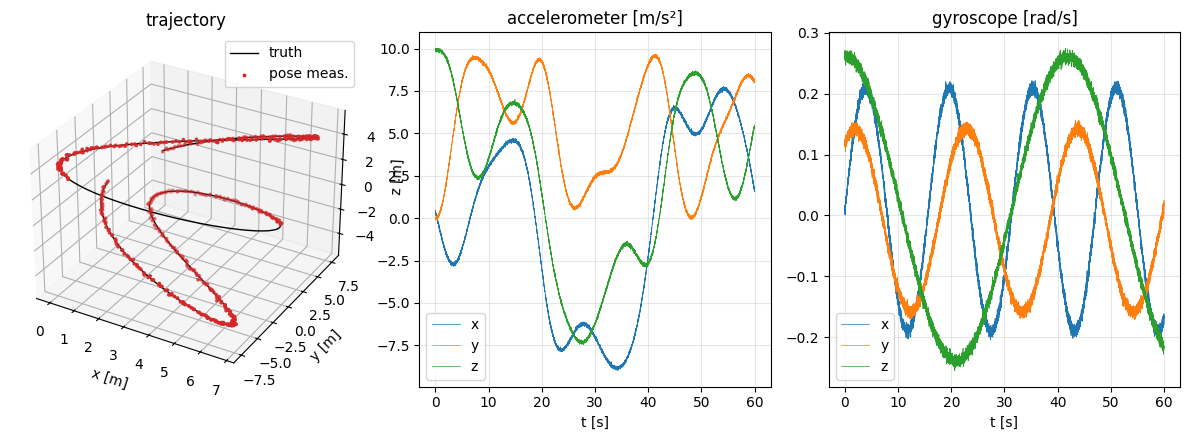

In [10]:
fig = plt.figure(figsize=(12, 4.5))
ax3 = fig.add_subplot(1, 3, 1, projection="3d")
ax3.plot(truth.px, truth.py, truth.pz, "k", lw=1, label="truth")
ax3.scatter(pose.px, pose.py, pose.pz, s=3, c="tab:red", label="pose meas.")
ax3.set_xlabel("x [m]"); ax3.set_ylabel("y [m]"); ax3.set_zlabel("z [m]"); ax3.legend()
ax3.set_title("trajectory")

ax = fig.add_subplot(1, 3, 2)
ax.plot(imu.t, imu[["ax", "ay", "az"]].to_numpy(), lw=0.5)
ax.set_title("accelerometer [m/s²]"); ax.set_xlabel("t [s]"); ax.legend(["x", "y", "z"])
ax = fig.add_subplot(1, 3, 3)
ax.plot(imu.t, imu[["wx", "wy", "wz"]].to_numpy(), lw=0.5)
ax.set_title("gyroscope [rad/s]"); ax.set_xlabel("t [s]"); ax.legend(["x", "y", "z"])
plt.tight_layout()

Look at the scale of the accelerometer signal. The vehicle's own acceleration is at most $0.3$ m/s², yet the readings swing between about $-9$ and $+10$ m/s². An accelerometer measures specific force, so almost everything you see is gravity, redistributed across the axes as the vehicle rolls and pitches (at $t=0$ the body is level and $z$ reads $+9.8$). To recover the tiny motion signal, the filter must subtract gravity using its attitude estimate. This is why a small attitude error is so harmful. A $1°$ tilt error leaves $9.81\sin 1° \approx 0.17$ m/s² of gravity in the wrong axis, which becomes about $8.5$ m of position error after only $10$ s.

In the 3D plot, the stretch of black line without red dots is the dropout window.

## 7. Running the filter

We initialise from the first pose measurement, guess zero velocity (the truth is about $1.6$ m/s, so we give velocity a large initial uncertainty) and assume zero biases.

In [11]:
def run_eskf(imu, pose, params, x0, P0, sigma_p, sigma_theta, use_pose=True):
    """Run the filter over time-stamped logs. Pose measurements with a timestamp up to the
    current IMU time are applied before the next prediction. Logs the posterior at every IMU step."""
    f = ESKF(params, x0, P0)
    t_imu = imu["t"].to_numpy()
    A, W = imu[["ax", "ay", "az"]].to_numpy(), imu[["wx", "wy", "wz"]].to_numpy()
    t_pose = pose["t"].to_numpy()
    Pm, Qm = pose[["px", "py", "pz"]].to_numpy(), pose[["qw", "qx", "qy", "qz"]].to_numpy()

    n = len(t_imu)
    log = {k: np.zeros((n + 1, d)) for k, d in [("p", 3), ("v", 3), ("q", 4), ("ab", 3), ("wb", 3), ("Pdiag", 15)]}
    log["t"] = np.r_[t_imu, 2 * t_imu[-1] - t_imu[-2]]
    log["P"], nis, j = np.zeros((n + 1, 15, 15)), [], 0
    for k in range(n + 1):
        t = log["t"][k]
        while use_pose and j < len(t_pose) and t_pose[j] <= t + 1e-9:     # correct
            nis.append((t_pose[j], f.update_pose(Pm[j], Qm[j], sigma_p, sigma_theta)))
            j += 1
        for key in ("p", "v", "q", "ab", "wb"):                            # log
            log[key][k] = f.x[key]
        log["P"][k], log["Pdiag"][k] = f.P, np.diag(f.P)
        if k < n:                                                          # predict
            f.predict(A[k], W[k], t_imu[k + 1] - t_imu[k] if k + 1 < n else t_imu[k] - t_imu[k - 1])
    log["nis"] = np.array(nis)
    return log

In [12]:
params = ESKFParams(cfg.sigma_an, cfg.sigma_wn, cfg.sigma_aw, cfg.sigma_ww, cfg.gravity)

x0 = dict(p=pose.loc[0, ["px", "py", "pz"]].to_numpy(),
          v=np.zeros(3),
          q=pose.loc[0, ["qw", "qx", "qy", "qz"]].to_numpy())
P0 = np.diag(np.r_[np.full(3, 0.1**2),               # position   [m²]
                   np.full(3, 2.0**2),               # velocity   [(m/s)²]
                   np.full(3, np.deg2rad(5)**2),     # attitude   [rad²]
                   np.full(3, 0.2**2),               # accel bias [(m/s²)²]
                   np.full(3, 0.02**2)])             # gyro bias  [(rad/s)²]

log = run_eskf(imu, pose, params, x0, P0, cfg.sigma_p, cfg.sigma_theta)

# errors w.r.t. ground truth, in error-state coordinates
t = log["t"]
T = {k: truth[c].to_numpy() for k, c in [("p", ["px", "py", "pz"]), ("v", ["vx", "vy", "vz"]),
                                          ("q", ["qw", "qx", "qy", "qz"]),
                                          ("ab", ["abx", "aby", "abz"]), ("wb", ["wbx", "wby", "wbz"])]}
err = np.hstack([T["p"] - log["p"], T["v"] - log["v"],
                 np.array([q_boxminus(T["q"][k], log["q"][k]) for k in range(len(t))]),
                 T["ab"] - log["ab"], T["wb"] - log["wb"]])
sig = np.sqrt(log["Pdiag"])

def shade(ax):
    ax.axvspan(*cfg.dropout, color="grey", alpha=0.15, lw=0)

def plot_block(idx, scale, ylabel, title, ylim=None):
    fig, axs = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
    for i, (a, c) in enumerate(zip(axs, "xyz")):
        a.plot(t, scale * err[:, idx + i], lw=0.8, label="error")
        a.fill_between(t, -3*scale*sig[:, idx + i], 3*scale*sig[:, idx + i], color="C1", alpha=0.25, label="±3σ")
        shade(a); a.set_title(f"{title} {c}"); a.set_xlabel("t [s]")
        if ylim: a.set_ylim(ylim)
    axs[0].set_ylabel(ylabel); axs[0].legend(loc="upper left")
    plt.tight_layout()

print(f"position RMSE (whole run)       : {np.sqrt(np.mean(np.sum(err[:, 0:3]**2, 1)))*100:.1f} cm")
m = (t > 5) & ((t < cfg.dropout[0]) | (t > cfg.dropout[1] + 2))
print(f"position RMSE (with measurements): {np.sqrt(np.mean(np.sum(err[m, 0:3]**2, 1)))*100:.1f} cm")
print(f"attitude RMSE (with measurements): {np.degrees(np.sqrt(np.mean(np.sum(err[m, 6:9]**2, 1)))):.2f} deg")

position RMSE (whole run)       : 14.3 cm
position RMSE (with measurements): 3.3 cm
attitude RMSE (with measurements): 0.32 deg


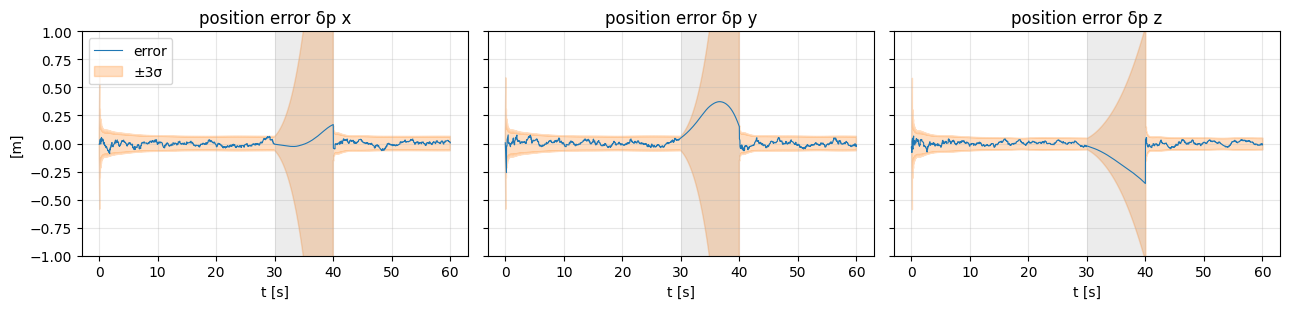

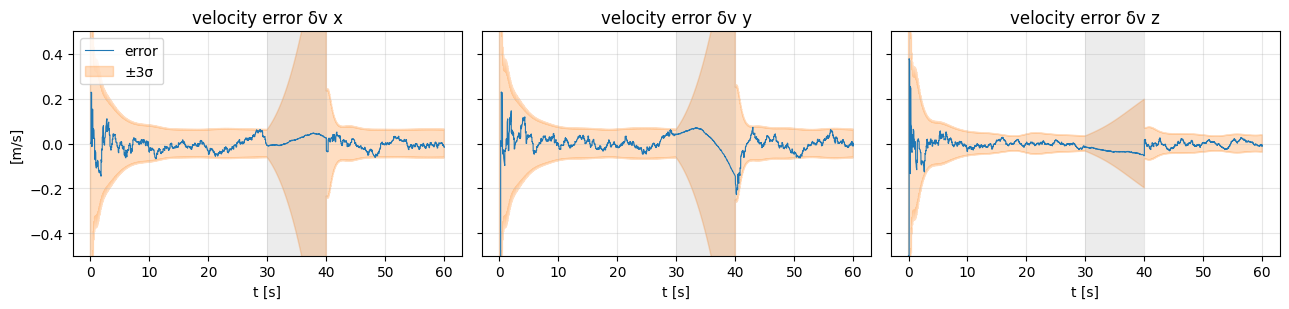

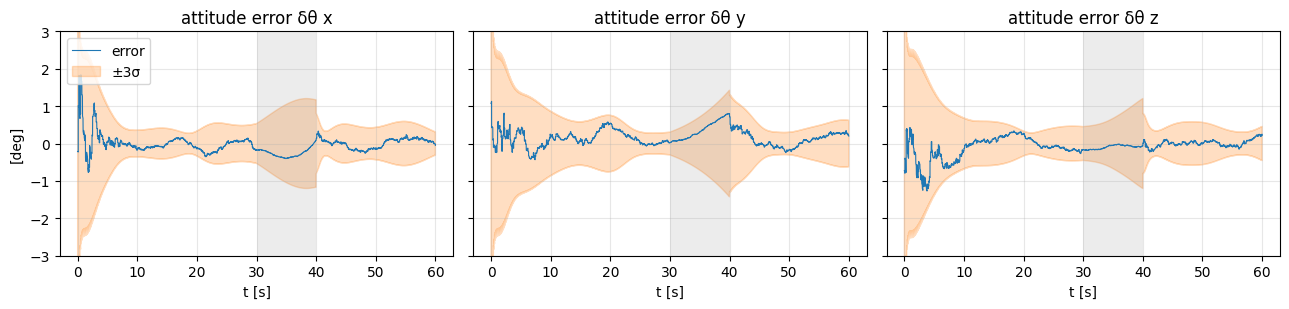

In [13]:
plot_block(0, 1.0, "[m]", "position error δp", ylim=(-1.0, 1.0))
plot_block(3, 1.0, "[m/s]", "velocity error δv", ylim=(-0.5, 0.5))
plot_block(6, np.degrees(1), "[deg]", "attitude error δθ", ylim=(-3, 3))

Things to notice:

* The error (blue) stays inside the $\pm3\sigma$ envelope (orange). The filter's uncertainty is a truthful description of its actual error. Section 8 tests this properly.
* Velocity was initialised $1.6$ m/s wrong and converges within a second, although velocity is never measured. It is observed through the change of position over time.
* In the grey dropout window the $\pm3\sigma$ envelope opens quickly, fastest in horizontal position, where tilt errors map gravity into $x$ and $y$ (as explained in Section 6). The actual error also grows, but stays inside the envelope.
* When measurements return at $t = 40$ s, the filter snaps back in one update.

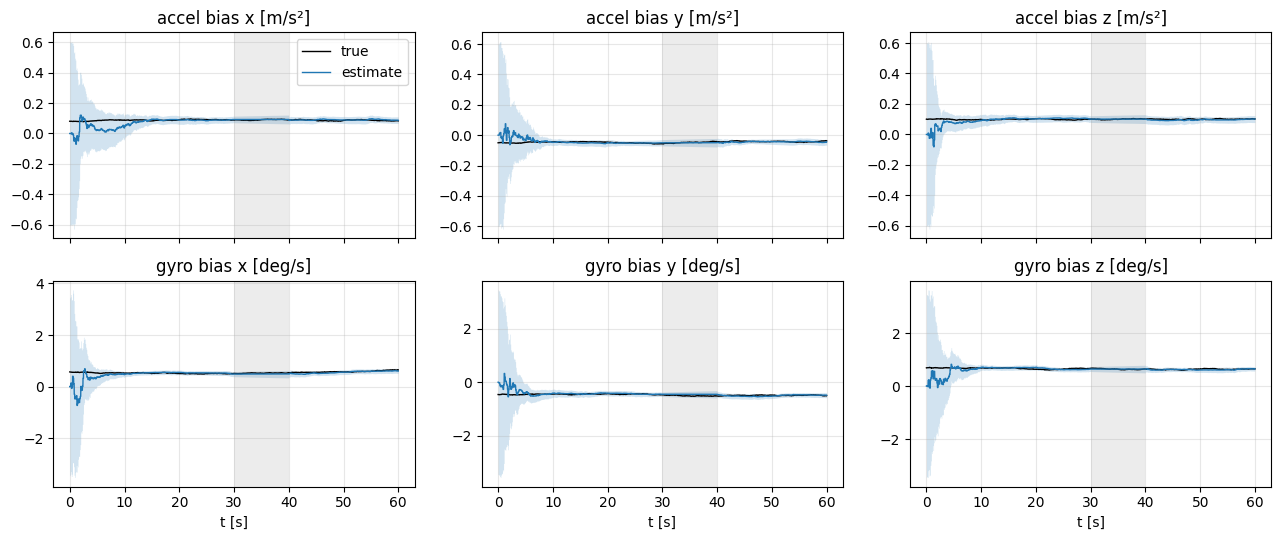

In [14]:
fig, axs = plt.subplots(2, 3, figsize=(13, 5.5), sharex=True)
for i, c in enumerate("xyz"):
    for row, (key, idx, unit, sc) in enumerate([("ab", 9, "m/s²", 1), ("wb", 12, "deg/s", np.degrees(1))]):
        a = axs[row, i]
        a.plot(t, sc * T[key][:, i], "k", lw=1, label="true")
        a.plot(t, sc * log[key][:, i], "C0", lw=1, label="estimate")
        a.fill_between(t, sc*(log[key][:, i] - 3*sig[:, idx+i]), sc*(log[key][:, i] + 3*sig[:, idx+i]),
                       color="C0", alpha=0.2, lw=0)
        shade(a); a.set_title(f"{'accel' if key=='ab' else 'gyro'} bias {c} [{unit}]")
axs[0, 0].legend(); [a.set_xlabel("t [s]") for a in axs[1]]
plt.tight_layout()

The biases start at zero and are pulled towards the truth. Gyro biases converge quickly because orientation is measured directly. Accelerometer biases take longer: the filter must separate "the accelerometer is biased" from "the vehicle is tilted" (both change the gravity projection), and that separation only becomes possible once the vehicle has rotated enough. This is an **observability** question. Try Exercise 3 to see what happens with a vehicle that never rotates.

### 7.1 Why bother? Pure IMU dead reckoning

Now run the same filter but *never* apply a pose update. This is pure strapdown integration, starting from the perfect initial state.

IMU-only position error after 60 s: 3722 m


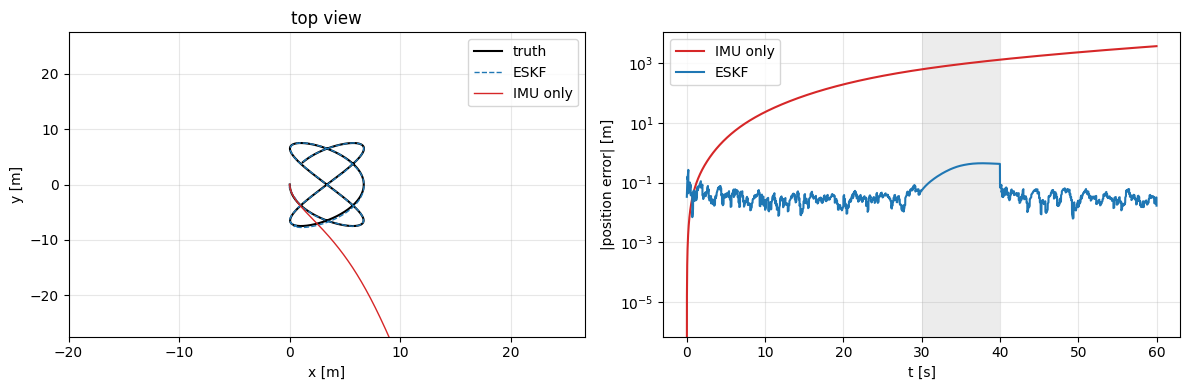

In [15]:
x0_perfect = dict(p=T["p"][0], v=T["v"][0], q=T["q"][0], ab=np.zeros(3), wb=np.zeros(3))
dr = run_eskf(imu, pose, params, x0_perfect, P0 * 1e-6, cfg.sigma_p, cfg.sigma_theta, use_pose=False)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(T["p"][:, 0], T["p"][:, 1], "k", lw=1.5, label="truth")
axs[0].plot(log["p"][:, 0], log["p"][:, 1], "C0--", lw=1, label="ESKF")
axs[0].plot(dr["p"][:, 0], dr["p"][:, 1], "C3", lw=1, label="IMU only")
axs[0].set_xlim(T["p"][:, 0].min() - 20, T["p"][:, 0].max() + 20)
axs[0].set_ylim(T["p"][:, 1].min() - 20, T["p"][:, 1].max() + 20)
axs[0].set_xlabel("x [m]"); axs[0].set_ylabel("y [m]"); axs[0].set_title("top view"); axs[0].legend()
axs[1].semilogy(t, np.linalg.norm(T["p"] - dr["p"], axis=1), "C3", label="IMU only")
axs[1].semilogy(t, np.linalg.norm(err[:, 0:3], axis=1) + 1e-4, "C0", label="ESKF")
shade(axs[1]); axs[1].set_xlabel("t [s]"); axs[1].set_ylabel("|position error| [m]"); axs[1].legend()
plt.tight_layout()
print(f"IMU-only position error after {t[-1]:.0f} s: {np.linalg.norm(T['p'][-1] - dr['p'][-1]):.0f} m")

Uncorrected biases are integrated twice, so position error grows roughly with $t^2$ (and faster once attitude drifts). The IMU is excellent over short horizons and useless over long ones. The pose sensor is the opposite: noisy but drift-free. The ESKF takes the best of both.

## 8. Is the filter honest? Consistency tests

A filter can have a small error and still be wrong about *how* uncertain it is, which is dangerous when its covariance is used downstream (gating, fusion, planning). Two standard tests (Bar-Shalom et al., *Estimation with Applications to Tracking and Navigation*, Sec. 5.4):

**NEES** (normalised estimation error squared) needs ground truth:
$$\epsilon_k = \delta\mathbf x_k^\top\,\mathbf P_k^{-1}\,\delta\mathbf x_k \;\sim\; \chi^2_{15} \quad\text{if the filter is consistent.}$$

Averaged over $N$ Monte Carlo runs, $N\bar\epsilon_k \sim \chi^2_{15N}$, which gives a 95% acceptance band.

**NIS** (normalised innovation squared) needs *no* ground truth, so it also works on real data:
$$\nu_k = \mathbf r_k^\top\,\mathbf S_k^{-1}\,\mathbf r_k \;\sim\; \chi^2_{6}.$$

For NEES we run $N$ independent datasets, each with a random initial error drawn from $\mathbf P_0$ (otherwise the initial error would not match the initial covariance). This takes about 20 seconds.

mean NEES = 16.20  (ideal 15), fraction inside 95% band = 88%
mean NIS  = 6.03  (ideal 6)


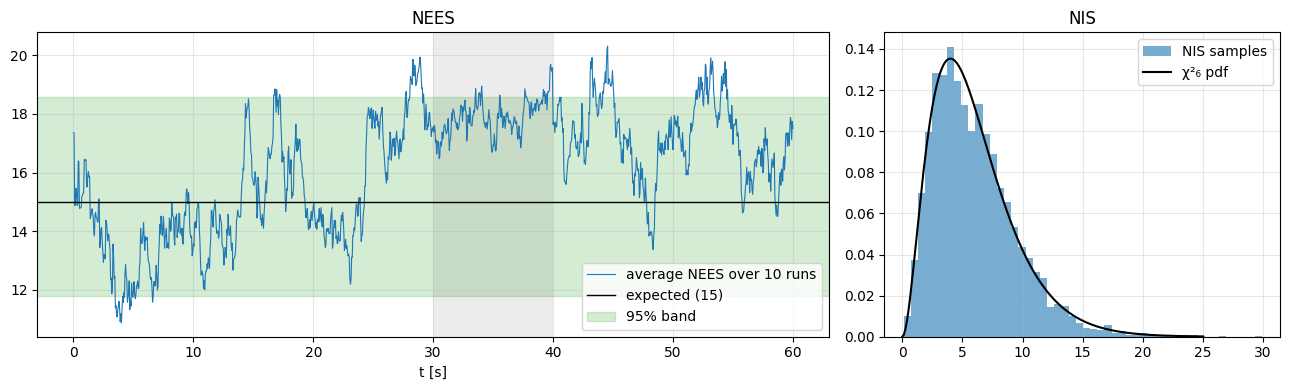

In [16]:
N, stride = 10, 10
P0_mc = np.diag(np.r_[np.full(3, 0.1**2), np.full(3, 0.1**2), np.full(3, np.deg2rad(5)**2),
                      np.full(3, 0.15**2), np.full(3, 0.02**2)])
L = np.linalg.cholesky(P0_mc)
nees_runs, nis_all = [], []
for s in range(N):
    c = SimConfig(seed=100 + s)
    tr, im, po = simulate(c)
    d = L @ np.random.default_rng(1000 + s).standard_normal(15)   # x_true = x0 ⊕ d  ->  x0 = x_true ⊖ d
    T0 = {k: tr.loc[0, cols].to_numpy() for k, cols in
          [("p", ["px","py","pz"]), ("v", ["vx","vy","vz"]), ("q", ["qw","qx","qy","qz"]),
           ("ab", ["abx","aby","abz"]), ("wb", ["wbx","wby","wbz"])]}
    x0_mc = dict(p=T0["p"] - d[0:3], v=T0["v"] - d[3:6], q=q_boxplus(T0["q"], -d[6:9]),
                 ab=T0["ab"] - d[9:12], wb=T0["wb"] - d[12:15])
    lg = run_eskf(im, po, params, x0_mc, P0_mc, c.sigma_p, c.sigma_theta)
    Tq = tr[["qw","qx","qy","qz"]].to_numpy()
    e = []
    for k in range(0, len(tr), stride):
        dx = np.r_[tr.loc[k, ["px","py","pz"]].to_numpy() - lg["p"][k],
                   tr.loc[k, ["vx","vy","vz"]].to_numpy() - lg["v"][k],
                   q_boxminus(Tq[k], lg["q"][k]),
                   tr.loc[k, ["abx","aby","abz"]].to_numpy() - lg["ab"][k],
                   tr.loc[k, ["wbx","wby","wbz"]].to_numpy() - lg["wb"][k]]
        e.append(dx @ np.linalg.solve(lg["P"][k], dx))
    nees_runs.append(e); nis_all.append(lg["nis"][:, 1])

anees = np.mean(nees_runs, axis=0)
t_nees = lg["t"][::stride]
lo, hi = chi2.ppf([0.025, 0.975], 15 * N) / N
nis = np.concatenate(nis_all)

fig, axs = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [2, 1]})
axs[0].plot(t_nees, anees, lw=0.8, label=f"average NEES over {N} runs")
axs[0].axhline(15, color="k", lw=1, label="expected (15)")
axs[0].axhspan(lo, hi, color="C2", alpha=0.2, label="95% band")
shade(axs[0]); axs[0].set_xlabel("t [s]"); axs[0].legend(); axs[0].set_title("NEES")
xs = np.linspace(0, 25, 200)
axs[1].hist(nis, bins=50, density=True, alpha=0.6, label="NIS samples")
axs[1].plot(xs, chi2.pdf(xs, 6), "k", label="χ²₆ pdf"); axs[1].legend(); axs[1].set_title("NIS")
plt.tight_layout()
print(f"mean NEES = {anees.mean():.2f}  (ideal 15), fraction inside 95% band = {np.mean((anees > lo) & (anees < hi)):.0%}")
print(f"mean NIS  = {nis.mean():.2f}  (ideal 6)")

The NIS histogram matches the $\chi^2_6$ density very well, and the average NEES stays in the neighbourhood of 15. Look closely, though: the NEES drifts slightly high in the second half and leaves the band now and then. The filter is consistent, but mildly over-confident. Likely contributors are the second-order terms dropped from $\mathbf F_x$ (Section 4.3) and the first-order approximations in the update and reset, and with only $N=10$ runs the average itself is still noisy. Increase `N` to separate the two effects. A NEES that sits far **above** the band means the filter is over-confident (its $\mathbf P$ is too small, typical when $\mathbf Q$ is under-tuned or the linearisation is poor). A NEES far **below** means it is too pessimistic and ignores information it could use.

On real data, NIS is the tool you have. Try Exercise 2 to see how mistuning shows up.

## 9. Exercises

1. **Second-order terms in $\mathbf F_x$.** Add $-\tfrac12\mathbf R[\mathbf a]_\times\Delta t^2$ and $-\tfrac12\mathbf R\Delta t^2$ to the $\delta\mathbf p$ row of `error_state_jacobian` (Section 4) and rerun the numerical check of Section 4.3. Does the NEES change noticeably at 200 Hz? What about at 20 Hz?
2. **Mistuning.** Run Section 8 with `ESKFParams(sigma_an=0.005, ...)` (10× too optimistic) and then with 10× too pessimistic noise. Watch NEES and NIS leave their bands.
3. **Observability.** Set the angular rate in `true_motion` (Section 6) to zero. Can the filter still separate accelerometer bias from tilt? Look at the bias plots and at the corresponding blocks of $\mathbf P$.
4. **Position-only updates.** Replace `update_pose` with `update_position` in `run_eskf` (Section 7). Which states lose accuracy? Why is yaw hit hardest?
5. **Global vs local error.** Solà Sec. 7 defines the orientation error in the world frame, $\mathbf q_t = \mathrm{Exp}(\delta\boldsymbol\theta)\otimes\mathbf q$. Rewrite $\mathbf F_x$, $\mathbf H$ and $\mathbf G$ for that convention and check that the results match.
6. **Estimate gravity.** Solà's full filter includes $\mathbf g$ in the state (18-dim error state). Add it and initialise it wrong by a few degrees.
7. **Your own data.** Replace the files in `data/` with a real IMU and pose log (same columns) and inspect the NIS. Remember to express the IMU in the body frame the pose refers to, and to handle the IMU-to-body extrinsic calibration.

## References

* J. Solà, *Quaternion kinematics for the error-state Kalman filter*, 2017. [arXiv:1711.02508](https://arxiv.org/abs/1711.02508)
* R. Labbe, *Kalman and Bayesian Filters in Python*, chapter 11: Extended Kalman Filters. [GitHub](https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python)
* Y. Bar-Shalom, X. R. Li, T. Kirubarajan, *Estimation with Applications to Tracking and Navigation*, Wiley, 2001.
* J. Solà, J. Deray, D. Atchuthan, *A micro Lie theory for state estimation in robotics*, 2018. [arXiv:1812.01537](https://arxiv.org/abs/1812.01537)